In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, get_scheduler
from torch.utils.data import DataLoader
from datasets import Dataset
import torch
from torchmetrics import Accuracy
from torch import nn, softmax
import torch.nn.functional as F
from torch.optim import AdamW
from transformers import BertForSequenceClassification
from tqdm.auto import tqdm
import evaluate
import itertools
from torch.nn import CrossEntropyLoss
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Importing the dataset

In [2]:
df_feature_engineered = pd.read_parquet('df_feature_engineering.parquet')
df_feature_engineered.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,...,label_pants-fire,label_true,statement_embedding,subject_embedding,state_info_encoded,party_affiliation_encoded,speaker_job_title_embedding,context_embedding,sentiment_polarity,sentiment_subjectivity
0,7874.json,half-true,new jersey pension system solvent,"pensions,state-finances",13th district gop slate,unknown,new jersey,republican,0.0,0.0,...,False,False,"[-0.012083505280315876, 0.04291439801454544, -...","[-0.00025623306282795966, 0.07373839616775513,...",31,8,"[-0.04310261458158493, 0.06563700735569, -0.06...","[-0.09551207721233368, 0.00916997715830803, 0....",0.136364,0.455
1,2287.json,pants-fire,president obama muslim,"candidates-biography,obama-birth-certificate,r...",18 percent american public,unknown,unknown,other,0.0,0.0,...,True,False,"[0.03861546143889427, 0.09793295711278915, -0....","[0.018359249457716942, -0.0027450351044535637,...",45,7,"[-0.04310261458158493, 0.06563700735569, -0.06...","[-0.02431786246597767, -0.017890894785523415, ...",0.000000,0.000
2,13412.json,true,test share fact widget,technology,18 percent american public,unknown,unknown,other,0.0,0.0,...,False,True,"[0.008106998167932034, 0.016036681830883026, -...","[-0.05337578058242798, 0.08707483857870102, -0...",45,7,"[-0.04310261458158493, 0.06563700735569, -0.06...","[-0.06791267544031143, -0.015540339052677155, ...",0.000000,0.000
3,2426.json,barely-true,new health care law cut billion medicare hurt ...,"health-care,medicare,message-machine",60 plus association,unknown,unknown,other,2.0,0.0,...,False,False,"[-0.050847914069890976, 0.03176962584257126, 0...","[-0.014705901965498924, 0.015529196709394455, ...",45,7,"[-0.04310261458158493, 0.06563700735569, -0.06...","[-0.10175438970327377, -0.002838208107277751, ...",0.136364,0.455
4,4832.json,pants-fire,independent payment advisory board created hea...,"government-regulation,health-care,message-mach...",60 plus association,unknown,unknown,other,2.0,0.0,...,True,False,"[-0.10781725496053696, 0.017993992194533348, 0...","[0.025282498449087143, 0.005831976421177387, -...",45,7,"[-0.04310261458158493, 0.06563700735569, -0.06...","[-0.036313507705926895, 0.03965112939476967, -...",0.068182,0.290


In [3]:
label_order = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']
label_2_index = {label: idx for idx, label in enumerate (label_order)}
index_2_label = {idx: label for label, idx in label_2_index.items()}
df_feature_engineered['label_encoded'] = df_feature_engineered['label'].map(label_2_index)
df_feature_engineered[['label', 'label_encoded']]

x = df_feature_engineered['statement']
y = df_feature_engineered['label_encoded'].values

# split into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# split into train and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

train_dataset = Dataset.from_dict({"text": x_train, "labels": y_train})
val_dataset = Dataset.from_dict({"text": x_val, "labels": y_val})
test_dataset = Dataset.from_dict({"text": x_test, "labels": y_test})

## Checking the length of statements to set max length

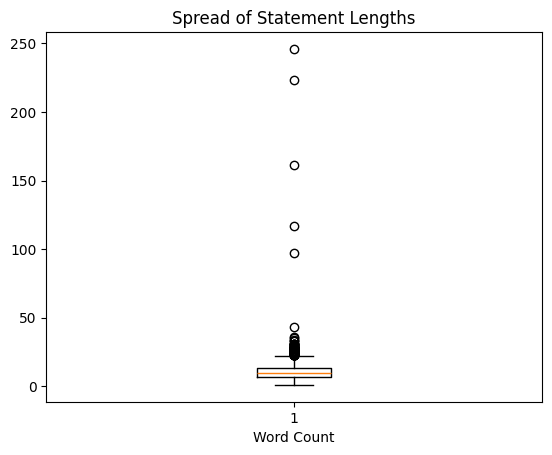

In [8]:
word_count = df_feature_engineered['statement'].apply(lambda x: len(x.split()))
plt.boxplot(word_count)
plt.title('Spread of Statement Lengths')
plt.xlabel('Word Count')
plt.show()

From the boxplot, we see that the lengths of the statements are mostly less than 20 words long. The longest statement is about 250 words long. We can use this information to set the number of tokens for our BERT model.

## Setting batch size and creating data loaders

In [28]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
max_length = 20
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=max_length)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_val = tokenized_val.remove_columns(["text"])
tokenized_test = tokenized_test.remove_columns(["text"])
tokenized_train.set_format("torch")
tokenized_val.set_format("torch")
tokenized_test.set_format("torch")

Map:   0%|          | 0/8182 [00:00<?, ? examples/s]

Map:   0%|          | 0/2046 [00:00<?, ? examples/s]

Map:   0%|          | 0/2558 [00:00<?, ? examples/s]

In [29]:
batch_size = 16
train_loader = DataLoader(tokenized_train, batch_size=16, shuffle=True)
val_loader = DataLoader(tokenized_val, batch_size=batch_size)
test_loader = DataLoader(tokenized_test, batch_size=batch_size)

## Initialising the model

In [23]:
class BERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.values 
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),  # Shape: (max_length,)
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }


In [24]:
def initialize_model():
    return BertForSequenceClassification.from_pretrained(
        "bert-base-uncased", 
        num_labels=6
    ).to(device)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = initialize_model()
model.to(device)
epochs = 5

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Training function and evaluation function

In [45]:
def bert_train(model, train_loader, params, epochs):
    learning_rate = params['learning_rate']
    num_warmup_steps_frac = params['num_warmup_steps']
    optimizer = AdamW(model.parameters(), lr=learning_rate)
    num_training_steps = len(train_loader) * epochs
    num_warmup_steps = int(num_warmup_steps_frac * num_training_steps)

    lr_scheduler = get_scheduler(
        name="linear",
        optimizer=optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps
    )

    for epoch in range(epochs):
        print(f"\nStarting epoch {epoch + 1}")
        total_train_loss = 0
        model.train()

        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(
                input_ids=batch['input_ids'],
                attention_mask=batch['attention_mask'],
                labels=batch['labels']  # <- directly pass integer labels
            )
            loss = outputs.loss
            total_train_loss += loss.item()

            loss.backward()
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()

        avg_train_loss = total_train_loss / len(train_loader)
        print(f"Epoch {epoch + 1}, Training Loss: {avg_train_loss:.4f}")

In [53]:
def bert_valid(model, val_loader, params, loss_fct):
    metric = Accuracy(task="multiclass", num_classes=6).to(device)
    model.eval()
    total_val_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(val_loader):
            batch = {k: v.to(device) for k, v in batch.items()}
            input_ids = batch['input_ids']
            attention_mask = batch['attention_mask']
            labels = batch['labels']  # No need for torch.argmax()

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())  # Move to CPU for sklearn
            all_labels.extend(labels.cpu().numpy())  

            loss = loss_fct(logits, labels)
            total_val_loss += loss.item()

            metric.update(preds.to(device), labels.to(device))

    avg_val_loss = total_val_loss / len(val_loader)
    accuracy = metric.compute()  
    metric.reset()  
    
    print(f"Loss: {avg_val_loss:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    return accuracy.item(), all_preds, all_labels

## Initial training and evaluation of the model

In [46]:
# initial model 
params = {
    'learning_rate': 1e-5,
    'num_warmup_steps': 0.1  
}

bert_train(model, train_loader, params, epochs)


Starting epoch 1
Epoch 1, Training Loss: 1.3981

Starting epoch 2
Epoch 2, Training Loss: 1.2683

Starting epoch 3
Epoch 3, Training Loss: 1.0739

Starting epoch 4
Epoch 4, Training Loss: 0.9107

Starting epoch 5
Epoch 5, Training Loss: 0.8073


In [54]:
loss_fct = CrossEntropyLoss()
bert_valid(model, val_loader, params, loss_fct)

Loss: 3.2595
Accuracy: 0.2390


(0.23900292813777924,
 [2,
  1,
  5,
  3,
  5,
  4,
  2,
  3,
  3,
  1,
  2,
  3,
  1,
  3,
  3,
  2,
  3,
  3,
  4,
  3,
  1,
  4,
  0,
  3,
  1,
  1,
  4,
  2,
  5,
  3,
  5,
  3,
  2,
  4,
  2,
  2,
  5,
  2,
  5,
  3,
  3,
  4,
  5,
  3,
  4,
  4,
  3,
  4,
  5,
  1,
  2,
  2,
  1,
  1,
  4,
  1,
  2,
  2,
  3,
  4,
  3,
  4,
  3,
  5,
  4,
  3,
  2,
  4,
  3,
  4,
  3,
  4,
  3,
  1,
  0,
  4,
  1,
  3,
  4,
  4,
  4,
  1,
  2,
  5,
  1,
  1,
  3,
  1,
  3,
  3,
  4,
  1,
  1,
  1,
  5,
  0,
  0,
  3,
  4,
  3,
  5,
  4,
  3,
  1,
  0,
  2,
  1,
  1,
  4,
  4,
  1,
  3,
  0,
  3,
  3,
  2,
  3,
  4,
  4,
  5,
  2,
  2,
  4,
  3,
  0,
  4,
  2,
  1,
  2,
  3,
  2,
  3,
  3,
  3,
  2,
  4,
  3,
  2,
  1,
  4,
  3,
  5,
  2,
  1,
  1,
  4,
  5,
  3,
  5,
  3,
  4,
  5,
  4,
  5,
  4,
  5,
  3,
  2,
  5,
  3,
  3,
  1,
  2,
  5,
  1,
  4,
  2,
  2,
  2,
  1,
  4,
  1,
  4,
  3,
  3,
  3,
  1,
  4,
  1,
  3,
  2,
  3,
  1,
  4,
  3,
  1,
  5,
  5,
  1,
  3,
  5,
  4,
  3,
  2,
  1,
  1

### Defining a function to get probability of a statement for each label. This function can be used for ensemble learning

In [ ]:
def get_bert_probs(model, data_loader):
    model.eval()
    all_probs = []

    with torch.no_grad():
        for batch in data_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])
            probs = softmax(outputs.logits, dim=1)
            all_probs.extend(probs.cpu().numpy())
    return all_probs

## Hyperparameter tuning to identify the best set of parameters

In [48]:
param_grid = {
    'learning_rate': [1e-5, 2e-5, 3e-5],
    'num_warmup_steps': [0.1, 0.2]  
}

def grid_search(train_loader, val_loader, param_grid, epochs):
    best_score = 0
    best_params = None
    all_combinations = list(itertools.product(*param_grid.values()))
    param_names = list(param_grid.keys())

    for i, combination in enumerate(all_combinations):
        params = dict(zip(param_names, combination))
        print(f"\nCombination {i+1}/{len(all_combinations)}: {params}")

        # Initialize fresh model for each combination
        model = initialize_model()
        loss_fct = torch.nn.CrossEntropyLoss()  # Using cross entropy loss as the loss function

        # Train and validate
        bert_train(model, train_loader, params, epochs)
        accuracy, all_preds, all_labels= bert_valid(model, val_loader, params, loss_fct)

        if accuracy > best_score:
            best_score = accuracy
            best_params = params

    print(f"\nBest parameters: {best_params}")
    print(f"Best Validation Accuracy: {best_score:.4f}")
    return all_preds, all_labels

grid_search(train_loader, val_loader, param_grid, epochs)


Combination 1/6: {'learning_rate': 1e-05, 'num_warmup_steps': 0.1}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Starting epoch 1
Epoch 1, Training Loss: 1.7739

Starting epoch 2
Epoch 2, Training Loss: 1.7226

Starting epoch 3
Epoch 3, Training Loss: 1.6725

Starting epoch 4
Epoch 4, Training Loss: 1.5929

Starting epoch 5
Epoch 5, Training Loss: 1.5193
Validation Loss: 1.7252
Validation Accuracy: 0.2590

Combination 2/6: {'learning_rate': 1e-05, 'num_warmup_steps': 0.2}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Starting epoch 1
Epoch 1, Training Loss: 1.7844

Starting epoch 2
Epoch 2, Training Loss: 1.7213

Starting epoch 3
Epoch 3, Training Loss: 1.6644

Starting epoch 4
Epoch 4, Training Loss: 1.5960

Starting epoch 5
Epoch 5, Training Loss: 1.5266
Validation Loss: 1.7389
Validation Accuracy: 0.2581

Combination 3/6: {'learning_rate': 2e-05, 'num_warmup_steps': 0.1}


...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Starting epoch 1
Epoch 1, Training Loss: 1.7574

Starting epoch 2
Epoch 2, Training Loss: 1.6811

Starting epoch 3
Epoch 3, Training Loss: 1.5210

Starting epoch 4
Epoch 4, Training Loss: 1.1889

Starting epoch 5
Epoch 5, Training Loss: 0.8608
Validation Loss: 2.1413
Validation Accuracy: 0.2620

Combination 6/6: {'learning_rate': 3e-05, 'num_warmup_steps': 0.2}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Starting epoch 1
Epoch 1, Training Loss: 1.7737

Starting epoch 2
Epoch 2, Training Loss: 1.7157

Starting epoch 3
Epoch 3, Training Loss: 1.6043

Starting epoch 4
Epoch 4, Training Loss: 1.3108

Starting epoch 5
Epoch 5, Training Loss: 0.9762
Validation Loss: 2.1477
Validation Accuracy: 0.2468

Best parameters: {'learning_rate': 2e-05, 'num_warmup_steps': 0.1}
Best Validation Accuracy: 0.2654


([3,
  1,
  3,
  1,
  3,
  4,
  1,
  4,
  3,
  1,
  1,
  3,
  1,
  3,
  1,
  4,
  3,
  2,
  5,
  4,
  1,
  2,
  3,
  3,
  1,
  3,
  4,
  0,
  5,
  2,
  3,
  3,
  1,
  3,
  1,
  3,
  3,
  1,
  5,
  3,
  3,
  4,
  2,
  4,
  5,
  3,
  2,
  4,
  5,
  1,
  2,
  3,
  1,
  1,
  3,
  3,
  1,
  2,
  1,
  5,
  3,
  2,
  1,
  1,
  3,
  5,
  3,
  3,
  3,
  3,
  5,
  3,
  2,
  2,
  0,
  1,
  1,
  4,
  4,
  3,
  4,
  2,
  2,
  1,
  3,
  1,
  1,
  1,
  1,
  3,
  1,
  3,
  3,
  1,
  4,
  3,
  0,
  4,
  4,
  3,
  4,
  4,
  3,
  1,
  2,
  4,
  0,
  1,
  4,
  3,
  2,
  1,
  0,
  1,
  3,
  2,
  4,
  4,
  2,
  1,
  0,
  1,
  4,
  3,
  0,
  3,
  2,
  1,
  3,
  5,
  2,
  3,
  3,
  5,
  3,
  4,
  4,
  4,
  1,
  5,
  3,
  5,
  2,
  1,
  1,
  4,
  5,
  3,
  3,
  3,
  4,
  3,
  1,
  5,
  5,
  3,
  3,
  3,
  4,
  3,
  3,
  3,
  1,
  5,
  0,
  5,
  2,
  3,
  2,
  1,
  4,
  1,
  4,
  4,
  3,
  3,
  1,
  4,
  0,
  3,
  1,
  3,
  1,
  4,
  5,
  1,
  3,
  2,
  2,
  4,
  4,
  1,
  3,
  2,
  1,
  3,
  1,
  4,
  3,
  1,


## Using parameters from hyperparameters to train and test the model

In [50]:
# From hyperparameter tuning
best_params = {'learning_rate': 2e-05, 'num_warmup_steps': 0.1}
bert_train(model, train_loader, best_params, epochs)
accuracy, all_preds, all_labels = bert_valid(model, test_loader, params, loss_fct)


Starting epoch 1
Epoch 1, Training Loss: 0.8995

Starting epoch 2
Epoch 2, Training Loss: 0.7580

Starting epoch 3
Epoch 3, Training Loss: 0.4927

Starting epoch 4
Epoch 4, Training Loss: 0.3251

Starting epoch 5
Epoch 5, Training Loss: 0.2171
Validation Loss: 3.3706
Validation Accuracy: 0.2353


## Evaluation

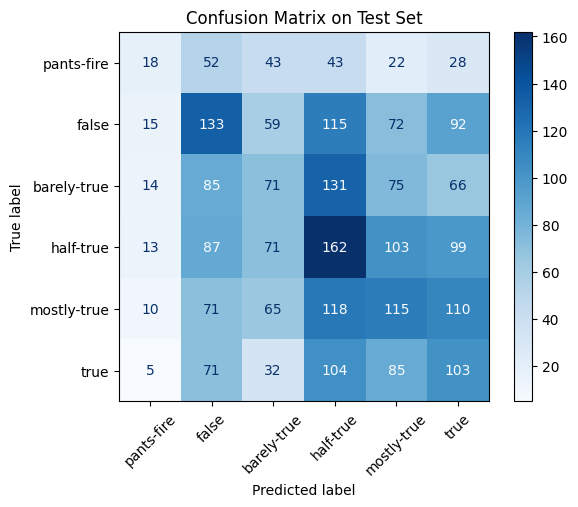

In [ ]:
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
cm = confusion_matrix(all_labels, all_preds)
class_names = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix on Test Set")
plt.show()


In [60]:
report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
for label in class_names:
    report_dict[label].pop('support', None)
for avg_key in ['macro avg', 'weighted avg']:
    report_dict[avg_key].pop('support', None)

clean_report_df = pd.DataFrame(report_dict).T
print(clean_report_df[['precision', 'recall', 'f1-score']].round(4))


              precision  recall  f1-score
pants-fire       0.2400  0.0874    0.1281
false            0.2665  0.2737    0.2701
barely-true      0.2082  0.1606    0.1814
half-true        0.2407  0.3028    0.2682
mostly-true      0.2436  0.2352    0.2393
true             0.2068  0.2575    0.2294
accuracy         0.2353  0.2353    0.2353
macro avg        0.2343  0.2195    0.2194
weighted avg     0.2352  0.2353    0.2307
